## 1. 라이브러리 임포트

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

## 2. 한글 폰트 설정

In [2]:
# 한글 폰트 설정
plt.rc('font', family='Malgun Gothic')
plt.rc('axes', unicode_minus=False)

## 3. 데이터 로드 및 전세 필터링

In [4]:
df = pd.read_csv("C:\\dev\\SKN18-FINAL-1TEAM\\data\\통합.csv", encoding="utf-8")
df_jeonse = df[df['거래_정보.거래방식'].str.contains('전세', na=False)].copy()

print(f"\n전세 데이터: {len(df_jeonse)}건")


전세 데이터: 1965건


## 4. 전세금 추출 및 매매가 역산
> 전세가율로 매매가 역산 (서울 평균 70%) : 
역산_매매가 = 전세금 / 0.7

In [57]:
def parse_korean_money(text):
    """1억 2,000만원-> 만원 단위로 변환"""
    if pd.isna(text):
        return 0

    text = text.replace(",", "").strip()
    text = re.sub(r"[^\d억만]", "", text)

    if "억" in text:
        parts = text.split("억")
        eok = int(parts[0]) if parts[0] else 0
        man = 0
        if len(parts) > 1 and "만" in parts[1]:
            man = int(parts[1].replace("만", ""))
        return eok * 10000 + man

    numbers = re.findall(r"\d+", text)
    if numbers:
        return int(numbers[0])

    return 0


# 전세금 추출
df_jeonse["전세금"] = df_jeonse["거래_정보.거래방식"].apply(parse_korean_money)

# 전세가율로 매매가 역산 (서울 평균 전세가율 70%)
df_jeonse["평당_전세금"] = df_jeonse["전세금"] / df_jeonse["전용면적_평"]

print(f"\n전세금 범위: {df_jeonse['전세금'].min():,.0f} ~ {df_jeonse['전세금'].max():,.0f} 만원")
print(f"평당 전세금 범위: {df_jeonse['평당_전세금'].min():,.0f} ~ {df_jeonse['평당_전세금'].max():,.0f} 만원")


전세금 범위: 2,500 ~ 60,000 만원
평당 전세금 범위: 333 ~ 5,709 만원


## 5. 전용면적 및 평당가 계산
> 평당가 = 역산_매매가 / 전용면적_평

In [58]:
def extract_area(value):
    """전용/공급면적에서 전용면적(m²) 추출"""
    if pd.isna(value):
        return None
    try:
        text = str(value).replace(" ", "").strip()
        area_str = text.split('/')[0].replace("m2", "")
        return float(area_str)
    except:
        return None


df_jeonse["전용면적_m2"] = df_jeonse["매물_정보.전용/공급면적"].apply(extract_area)
df_jeonse["전용면적_평"] = df_jeonse["전용면적_m2"] / 3.3

# 평당가 계산 (타겟)
df_jeonse["평당가"] = df_jeonse["역산_매매가"] / df_jeonse["전용면적_평"].replace(0, np.nan)

# 결측치 및 이상치 제거
df_jeonse = df_jeonse.dropna(subset=["전용면적_평", "평당가"])
df_jeonse = df_jeonse[df_jeonse["평당가"] > 0]  # 음수 제거

print(f"\n유효 데이터: {len(df_jeonse)}건")
print(f"평당가 범위: {df_jeonse['평당가'].min():,.0f} ~ {df_jeonse['평당가'].max():,.0f} 만원")


유효 데이터: 1327건
평당가 범위: 475 ~ 8,155 만원


## 6. feature 추출

In [59]:
# 관리비
def extract_management_fee(value):
    if pd.isna(value):
        return 0
    match = re.search(r'(\d+)\s*만원', str(value))
    return int(match.group(1)) if match else 0

df_jeonse["관리비"] = df_jeonse["거래_정보.관리비"].apply(extract_management_fee)
# print(df_jeonse['관리비'])

# 층 정보
def extract_floor(value):
    if pd.isna(value):
        return None
    parts = str(value).split('/')
    match = re.search(r'-?\d+', parts[0])
    return int(match.group(0)) if match else None

df_jeonse["층"] = df_jeonse["매물_정보.해당층/전체층"].apply(extract_floor)
# print(df_jeonse['층'])

# 방/욕실 개수
room_info = df_jeonse["매물_정보.방/욕실개수"].str.extract(r'(?P<방수>\d+)개/(?P<욕실수>\d+)개')
df_jeonse["방수"] = room_info["방수"].astype(int)
df_jeonse["욕실수"] = room_info["욕실수"].astype(int)
# print(df_jeonse[['방수', '욕실수']])

# 구/동 추출
def extract_gu_dong(addr):
    if pd.isna(addr):
        return (None, None)
    addr = str(addr).strip()
    gu_match = re.search(r'(\S+구)', addr)
    dong_match = re.search(r'(\S+?\d*(동|가))', addr)
    gu = gu_match.group(1) if gu_match else None
    dong = dong_match.group(1) if dong_match else None
    return (gu, dong)

df_jeonse["구"], df_jeonse["동"] = zip(*df_jeonse["주소_정보.전체주소"].apply(extract_gu_dong))

# 결측치 제거
df_jeonse = df_jeonse.dropna(subset=["구", "동", "층", "방수", "욕실수"])
# print(df_jeonse[['구', '동']].head())

print(f"\n최종 데이터: {len(df_jeonse)}건")


최종 데이터: 1327건


In [60]:
# IQR 방법으로 이상치 제거
Q1 = df_jeonse['평당가'].quantile(0.25)
Q3 = df_jeonse['평당가'].quantile(0.75)
IQR = Q3 - Q1

# 1.5 IQR 범위 밖 제거 (너무 극단적인 값)
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df_jeonse = df_jeonse[
    (df_jeonse['평당가'] >= lower_bound) & 
    (df_jeonse['평당가'] <= upper_bound)
]
print(f"\n이상치 제거 후 데이터: {len(df_jeonse)}건")


이상치 제거 후 데이터: 1327건


## 7. EDA

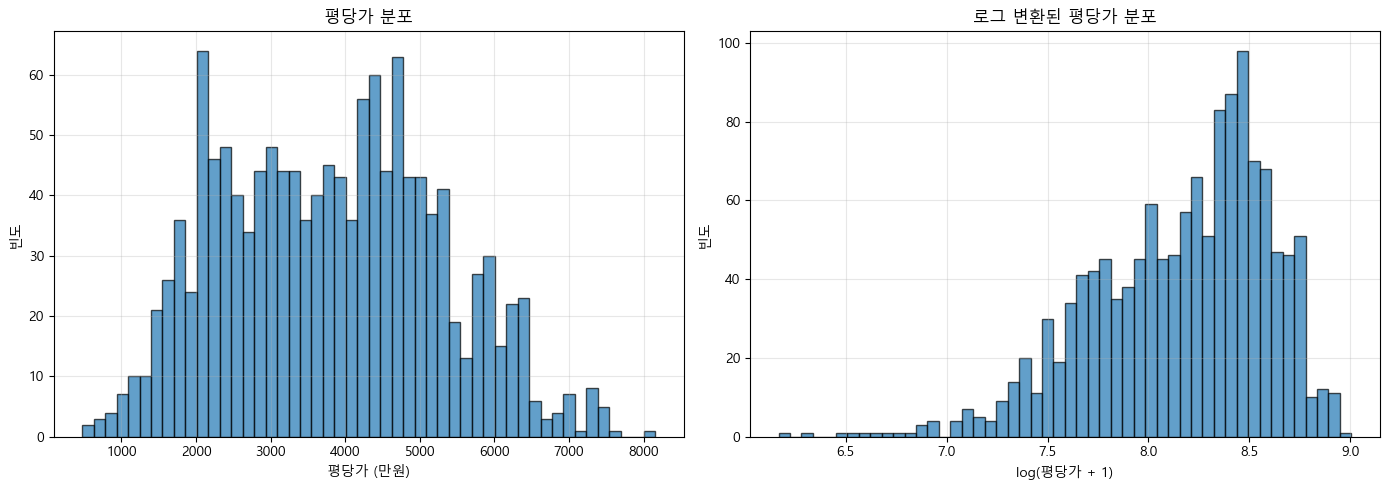

In [61]:
# 평당가 분포
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df_jeonse["평당가"], bins=50, edgecolor='black', alpha=0.7)
axes[0].set_title("평당가 분포")
axes[0].set_xlabel("평당가 (만원)")
axes[0].set_ylabel("빈도")
axes[0].grid(True, alpha=0.3)

axes[1].hist(np.log1p(df_jeonse["평당가"]), bins=50, edgecolor='black', alpha=0.7)
axes[1].set_title("로그 변환된 평당가 분포")
axes[1].set_xlabel("log(평당가 + 1)")
axes[1].set_ylabel("빈도")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("01_평당가_분포.png", dpi=150, bbox_inches='tight')
plt.show()

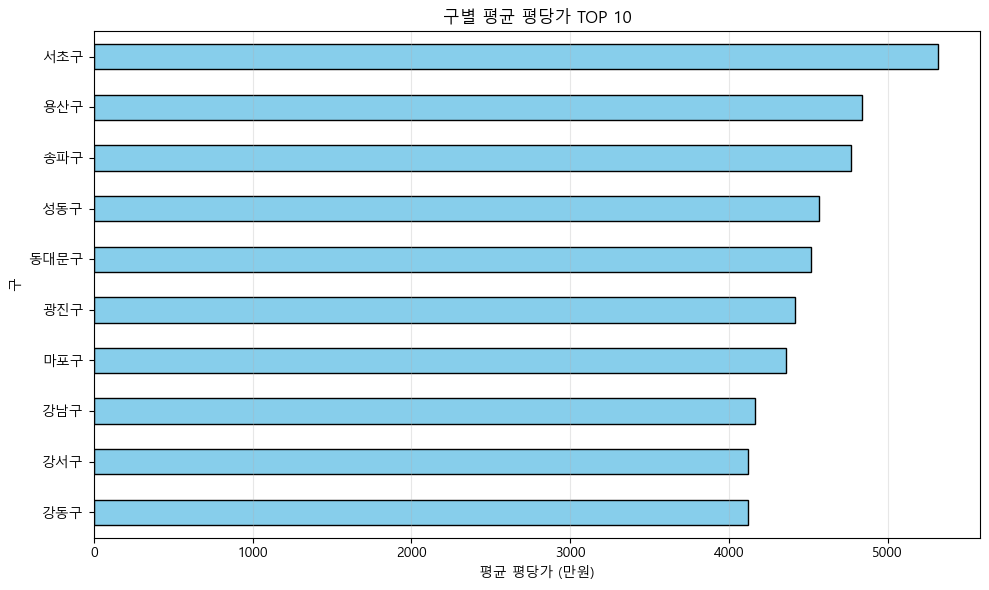

In [62]:
# 구별 평균 평당가 TOP 10
gu_avg = df_jeonse.groupby("구")["평당가"].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 6))
gu_avg.plot(kind='barh', color='skyblue', edgecolor='black')
plt.title("구별 평균 평당가 TOP 10")
plt.xlabel("평균 평당가 (만원)")
plt.ylabel("구")
plt.gca().invert_yaxis()
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig("02_구별_평균_평당가.png", dpi=150, bbox_inches='tight')
plt.show()

In [63]:
print("\n구별 평균 평당가 TOP 10:")
for idx, (gu, price) in enumerate(gu_avg.items(), 1):
    print(f"{idx:2d}. {gu}: {price:,.0f} 만원")


구별 평균 평당가 TOP 10:
 1. 서초구: 5,317 만원
 2. 용산구: 4,839 만원
 3. 송파구: 4,769 만원
 4. 성동구: 4,566 만원
 5. 동대문구: 4,517 만원
 6. 광진구: 4,419 만원
 7. 마포구: 4,358 만원
 8. 강남구: 4,164 만원
 9. 강서구: 4,122 만원
10. 강동구: 4,121 만원


## 8. ML용 Feature 준비

In [64]:
# 전체 층수 추출
def extract_total_floor(value):
    if pd.isna(value):
        return None
    parts = str(value).split('/')
    if len(parts) > 1:
        match = re.search(r'\d+', parts[1])
        return int(match.group(0)) if match else None
    return None

df_jeonse['전체층수'] = df_jeonse["매물_정보.해당층/전체층"].apply(extract_total_floor)

# 층수 비율 (몇 층 중 몇 층인지)
df_jeonse['층_비율'] = df_jeonse['층'] / df_jeonse['전체층수'].replace(0, np.nan)

# 저층/중층/고층 구분
df_jeonse['층_카테고리'] = pd.cut(df_jeonse['층_비율'], 
                                  bins=[0, 0.3, 0.7, 1.0], 
                                  labels=['저층', '중층', '고층'])

In [65]:
# 평수 구간 (소형/중형/대형)
df_jeonse['평수_구간'] = pd.cut(df_jeonse['전용면적_평'], 
                               bins=[0, 20, 30, 100], 
                               labels=['소형', '중형', '대형'])

# 방수 대비 평수 (평당 방 개수)
df_jeonse['평당_방수'] = df_jeonse['방수'] / df_jeonse['전용면적_평']

In [66]:
# 평당 관리비
df_jeonse['평당_관리비'] = df_jeonse['관리비'] / df_jeonse['전용면적_평']

In [67]:
# feature_cols = [
#     "평당가",
#     "전용면적_평",
#     "전용면적_m2",
#     "관리비",
#     "층",
#     "방수",
#     "욕실수",
#     "구",
#     "동"
# ]

# df_ml = df_jeonse[feature_cols].copy()

# # 구/동 인코딩
# for col in ["구", "동"]:
#     le = LabelEncoder()
#     df_ml[col] = le.fit_transform(df_ml[col].astype(str))

# print(f"\nML 데이터 크기: {df_ml.shape}")

In [68]:
# 구/동 빈도 인코딩
gu_freq = df_jeonse['구'].value_counts() / len(df_jeonse)
dong_freq = df_jeonse['동'].value_counts() / len(df_jeonse)
df_jeonse['구_빈도'] = df_jeonse['구'].map(gu_freq)
df_jeonse['동_빈도'] = df_jeonse['동'].map(dong_freq)

# 수동 Target Encoding (Leave-One-Out 방식으로 과적합 방지)
def target_encode_loo(df, col, target):
    """Leave-One-Out Target Encoding"""
    global_mean = df[target].mean()
    agg = df.groupby(col)[target].agg(['sum', 'count'])
    
    # 각 행에 대해 자기 자신을 제외한 평균 계산
    encoded = []
    for idx, row in df.iterrows():
        cat = row[col]
        target_val = row[target]
        
        # 해당 카테고리의 합계에서 현재 값을 빼고, 개수도 -1
        cat_sum = agg.loc[cat, 'sum'] - target_val
        cat_count = agg.loc[cat, 'count'] - 1
        
        # 개수가 0이면 전체 평균 사용
        if cat_count == 0:
            encoded.append(global_mean)
        else:
            encoded.append(cat_sum / cat_count)
    
    return encoded

df_jeonse['구_target_enc'] = target_encode_loo(df_jeonse, '구', '평당가')
df_jeonse['동_target_enc'] = target_encode_loo(df_jeonse, '동', '평당가')

# Feature 목록 (새로 추가된 feature 포함)
feature_cols = [
    "평당가",
    "전용면적_평",
    "전용면적_m2",
    "관리비",
    "층",
    "방수",
    "욕실수",
    "전체층수",
    "층_비율",
    "평당_방수",
    "평당_관리비",
    "구_빈도",
    "동_빈도",
    "구_target_enc",
    "동_target_enc"
]

# 결측치 제거
df_jeonse = df_jeonse.dropna(subset=feature_cols)

# ML용 DataFrame 생성
df_ml = df_jeonse[feature_cols].copy()

print(f"\nML 데이터 크기: {df_ml.shape}")
print(f"\n사용된 Feature 목록:")
for i, col in enumerate(feature_cols[1:], 1):  # 평당가 제외
    print(f"  {i:2d}. {col}")


ML 데이터 크기: (1327, 15)

사용된 Feature 목록:
   1. 전용면적_평
   2. 전용면적_m2
   3. 관리비
   4. 층
   5. 방수
   6. 욕실수
   7. 전체층수
   8. 층_비율
   9. 평당_방수
  10. 평당_관리비
  11. 구_빈도
  12. 동_빈도
  13. 구_target_enc
  14. 동_target_enc


## 10. XGBoost

#### 10-1. 데이터 분할

In [69]:
X = df_ml.drop(columns=["평당가"])
y = df_ml["평당가"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

#### 10-2. 로그 변환

In [70]:
y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)

print(f"Train: {len(X_train)}, Test: {len(X_test)}")

Train: 1061, Test: 266


#### 10-3. 모델 학습

In [71]:
# R^2 : 0.3599  -> 0.7665 -> 0.7798
model = XGBRegressor(
    n_estimators=1800, # 500 -> 1000
    learning_rate=0.018, # 0.05 -> 0.03
    max_depth=10, # 6 -> 8
    subsample=0.88, # 0.8
    colsample_bytree=0.88, # 0.8
    random_state=42,
    n_jobs=-1,
    gamma=0.03,                # 추가 (노드 분할 최소 손실) 0.1
    reg_alpha=0.03,            # L1 정규화 추가 0.1
    reg_lambda=1,             # L2 정규화 추가
    min_child_weight=3,       # 추가 (과적합 방지)
    tree_method='hist',       # 추가 (빠른 트리 생성 방법)
)

print("\n모델 학습 중...")
model.fit(X_train, y_train_log)

# Early Stopping 적용
# model.fit(
#     X_train, y_train_log,
#     eval_set=[(X_test, y_test_log)],
#     early_stopping_rounds=50,
#     verbose=100
# )


모델 학습 중...


,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.88
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


#### 10-4. 예측

In [72]:
y_pred_log = model.predict(X_test)
y_pred = np.expm1(y_pred_log)
y_test_orig = np.expm1(y_test_log)

print("✓ 모델 학습 완료")

✓ 모델 학습 완료


## 11. 모델 평가

In [ ]:
mae = mean_absolute_error(y_test_orig, y_pred)
rmse = np.sqrt(mean_squared_error(y_test_orig, y_pred))
r2 = r2_score(y_test_orig, y_pred)
mape = np.mean(np.abs((y_test_orig - y_pred) / y_test_orig)) * 100

print("\n" + "=" * 80)
print("전세 평당가 예측 모델 성능")
print("=" * 80)
print(f"MAE  : {mae:,.2f} 만원")
print(f"RMSE : {rmse:,.2f} 만원")
print(f"R²   : {r2:.4f}")
print(f"MAPE : {mape:.2f}%")
print("=" * 80)


전세 평당가 예측 모델 성능
MAE  : 454.41 만원
RMSE : 691.72 만원
R²   : 0.7798
MAPE : 15.89%


In [ ]:
# # 교차 검증
# from sklearn.model_selection import RandomizedSearchCV

# param_dist = {
#     'n_estimators': [1500, 1800, 2000, 2500],
#     'learning_rate': [0.015, 0.018, 0.02, 0.025],
#     'max_depth': [9, 10, 11],
#     'min_child_weight': [1, 2, 3],
#     'subsample': [0.85, 0.88, 0.9],
#     'colsample_bytree': [0.85, 0.88, 0.9],
#     'gamma': [0.01, 0.03, 0.05],
#     'reg_alpha': [0.01, 0.03, 0.05],
#     'reg_lambda': [1.5, 1.8, 2.0]
# }

# random_search = RandomizedSearchCV(
#     XGBRegressor(random_state=42, n_jobs=-1),
#     param_distributions=param_dist,
#     n_iter=30,
#     cv=5,
#     scoring='r2',
#     random_state=42,
#     n_jobs=-1,
#     verbose=2
# )

# random_search.fit(X_train, y_train_log)
# print(f"최적 파라미터: {random_search.best_params_}")
# print(f"최적 R^2: {random_search.best_score_:.4f}")

Fitting 5 folds for each of 30 candidates, totalling 150 fits
최적 파라미터: {'subsample': 0.88, 'reg_lambda': 2.0, 'reg_alpha': 0.05, 'n_estimators': 2000, 'min_child_weight': 3, 'max_depth': 9, 'learning_rate': 0.018, 'gamma': 0.01, 'colsample_bytree': 0.85}
최적 R^2: 0.7113


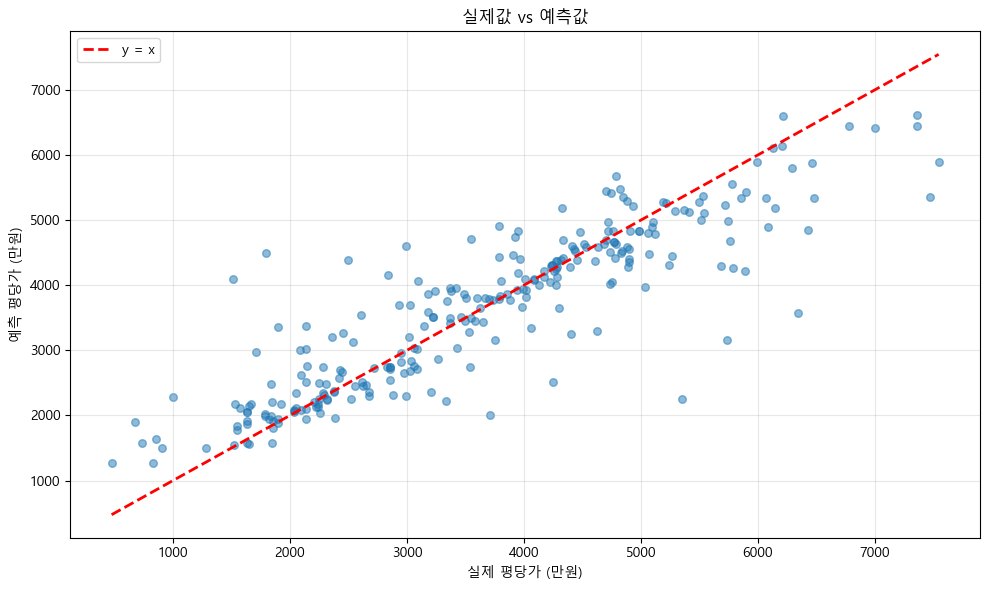

In [74]:
# 실제값 vs 예측값
plt.figure(figsize=(10, 6))
plt.scatter(y_test_orig, y_pred, alpha=0.5, s=30)

max_val = max(y_test_orig.max(), y_pred.max())
min_val = min(y_test_orig.min(), y_pred.min())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='y = x')

plt.xlabel("실제 평당가 (만원)")
plt.ylabel("예측 평당가 (만원)")
plt.title("실제값 vs 예측값")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("03_실제값_vs_예측값.png", dpi=150, bbox_inches='tight')
plt.show()

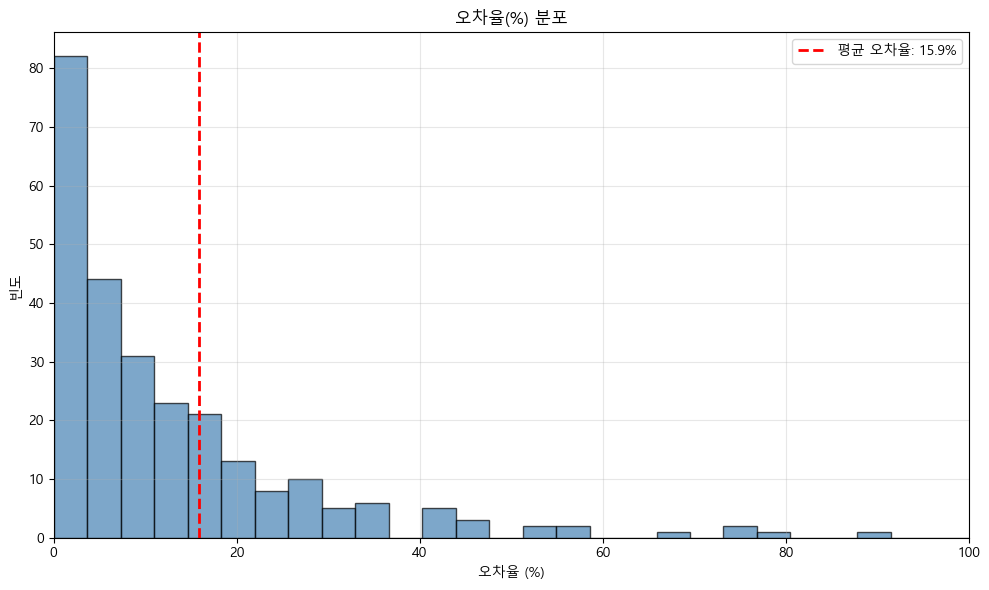

In [75]:
# 오차율 분포
error_rate = np.abs((y_test_orig - y_pred) / y_test_orig) * 100

plt.figure(figsize=(10, 6))
plt.hist(error_rate, bins=50, edgecolor='black', alpha=0.7, color='steelblue')
plt.xlim(0, 100)
plt.axvline(mape, color='red', linestyle='--', linewidth=2, label=f'평균 오차율: {mape:.1f}%')
plt.title("오차율(%) 분포")
plt.xlabel("오차율 (%)")
plt.ylabel("빈도")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("04_오차율_분포.png", dpi=150, bbox_inches='tight')
plt.show()


C:\Users\Playdata\AppData\Local\Temp\ipykernel_37008\3966108947.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feature_importance, x='중요도', y='특성', palette='viridis')


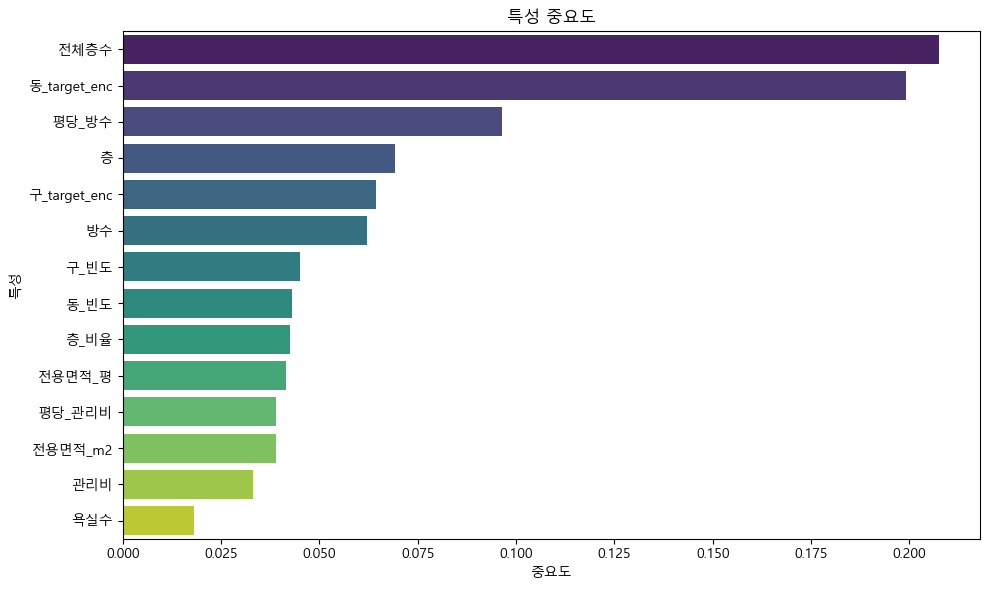


특성 중요도:
          특성      중요도
        전체층수 0.207605
동_target_enc 0.199175
       평당_방수 0.096438
           층 0.069181
구_target_enc 0.064278
          방수 0.062206
        구_빈도 0.045060
        동_빈도 0.042942
        층_비율 0.042594
      전용면적_평 0.041594
      평당_관리비 0.038939
     전용면적_m2 0.038854
         관리비 0.033085
         욕실수 0.018049


In [76]:
# 특성 중요도
feature_importance = pd.DataFrame({
    '특성': X.columns,
    '중요도': model.feature_importances_
}).sort_values('중요도', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance, x='중요도', y='특성', palette='viridis')
plt.title("특성 중요도")
plt.xlabel("중요도")
plt.ylabel("특성")
plt.tight_layout()
plt.savefig("05_특성_중요도.png", dpi=150, bbox_inches='tight')
plt.show()

print("\n특성 중요도:")
print(feature_importance.to_string(index=False))

## 12. 샘플 테스트

In [77]:
df_result = pd.DataFrame({
    "실제 평당가": y_test_orig.values[:20],
    "예측 평당가": y_pred[:20],
    "오차": y_test_orig.values[:20] - y_pred[:20],
    "오차율(%)": error_rate.values[:20]
})

print("\n" + "=" * 80)
print("예측 결과 샘플 (20개)")
print("=" * 80)
print(df_result.to_string(index=False))


print("\n" + "=" * 80)
print("분석 완료!")
print("=" * 80)
print(f"\n저장된 파일:")
print("  - 01_평당가_분포.png")
print("  - 02_구별_평균_평당가.png")
print("  - 03_실제값_vs_예측값.png")
print("  - 04_오차율_분포.png")
print("  - 05_특성_중요도.png")


예측 결과 샘플 (20개)
     실제 평당가      예측 평당가           오차     오차율(%)
4754.516236 4043.132080   711.384156  14.962283
3021.009750 3198.153564  -177.143815   5.863729
5858.277035 5341.145508   517.131528   8.827366
1514.987848 4097.266113 -2582.278266 170.448777
7470.640947 5353.759277  2116.881670  28.336011
5101.279318 4969.673340   131.605978   2.579862
1926.870748 2175.128662  -248.257914  12.883994
3737.709659 3778.444580   -40.734921   1.089836
4414.715719 4601.683594  -186.967875   4.235106
6431.494835 4845.289062  1586.205773  24.663096
4331.145886 4697.537598  -366.391712   8.459464
4174.025106 4127.822266    46.202841   1.106913
 732.411038 1576.265869  -843.854831 115.216018
1528.957529 2182.595947  -653.638418  42.750594
4017.360927 3812.837891   204.523037   5.090980
2376.152074 2363.026855    13.125218   0.552373
1843.481794 1575.565796   267.915998  14.533151
5722.261609 5233.479004   488.782605   8.541773
4439.194017 4529.271484   -90.077467   2.029140
1285.714286 1504.405029 